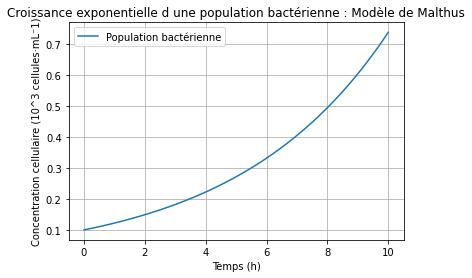

In [20]:
import numpy as np 
import matplotlib.pyplot as plt 
# Paramètres de la simulation
rmax = 0.2 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T= 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)
# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)
# Tracé du graphique
plt.title('Croissance exponentielle d une population bactérienne : Modèle de Malthus') # Titre du graphique
plt.plot(time, C, label='Population bactérienne') # Nom de la courbe
plt.xlabel('Temps (h)') # Axe des X
plt.ylabel('Concentration cellulaire (10^3 cellules·mL⁻1)') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()



C'est une courbe exponentielle.
Avec ce modèle exponentiel, on peut dire que C(t) = Ce^rt
On veut savoir quand la population double donc quand C(t) = 2C0 
2C0=C0e^rt
2=e^rt
ln(2)=rt
t=ln(2)/r

Si r = 0.4 t = 1.73 heure
Si r = 0.2 t = 3.5 heures (modèle de base)
Si r = 0.1 t = 6.93 heures
Si r = 0 la population ne double jamais 
Si r = -0.1 la population ne double jamais 

Plus le taux de corissance est grand plus le temps de doublement est court.
Quand le taux est positif la croissance est exponentielle et le doublement arrive d'autant plus vite que r est élevée.
quand le taux est nul ou négatif, il n'y a pas de doublement. 
Dans le modèle de Malthus, les ressources sont infinis. Des ressources limitées plus proches des conditions réelles feraient varier le rmax ce qui connditionnerait la croissance de la population. Une croissance finie dans un monde infini est impossible.


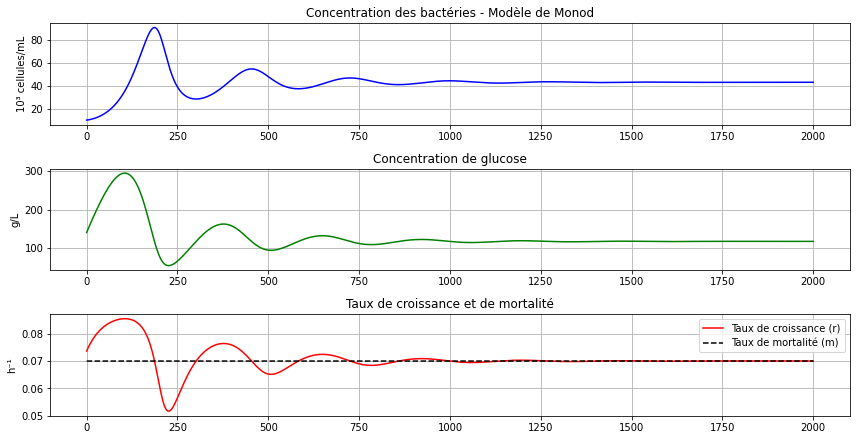

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()












La courbe bacterienne commence à croître puis atteint un maximum quand la croissance et la mortalité et se compensent.
La courbe du glocose diminue au cours du temps car il est consomm par les bacteries.
La courbe du taux de croissance baisse avec l'épuisement du substrat tandis que le taux de mortalité reste constant (m0 fixe)
Si le glucose devient trop faible, la population entre en déclin se qui explique l'écroulement observé.

La population s'écroule par limitation du substrat. Le facteur limitant est le glucose, pas la taille initiale de la population.

La population atteint son maximum lorsque la croissance et la mortalité se compensent. Graphiquement cela correspond au sommet de la courbe bacterienne. 

K=50

Pour maintenir la population dans le temps, il faut un apport régulier en glucose suffisemment important pour compenser sa consommation de façon à conserver un équilibre entre croissance et mortalité.

L'évolution des courbes montre d'abord une phase transitoire marquée par une forte augmentation (exponentielle) de la population bacterienne suivie d'oscillations avant l'établissement d'une courbe plus stable.
Le nouveau flux entrant de glucose compense en partie la consommation par les bactéries, ce qui limite l'épuisement du substrat.La population devient trop grande pour les ressources.
Le système cherche un équilibre entre 3 effets : la croissance liée à la disponibilité du glucose, la mortalité, et l'apport continu de substrat. Ceci conduit à de nombreuses fluctuations.
Au début, la forte croissance bacterienne est favorisée par la forte concentration en glucose. Lorsque celui ci est consommé, le taux de croissance diminue ce qui implique une baisse de la population.
Ces fluctuations sont donc la conséquence d'un ajustement dynamique entre apport croissance et mortalité.
Variation du taux de croissance lié à la disponibilité des ressources. 

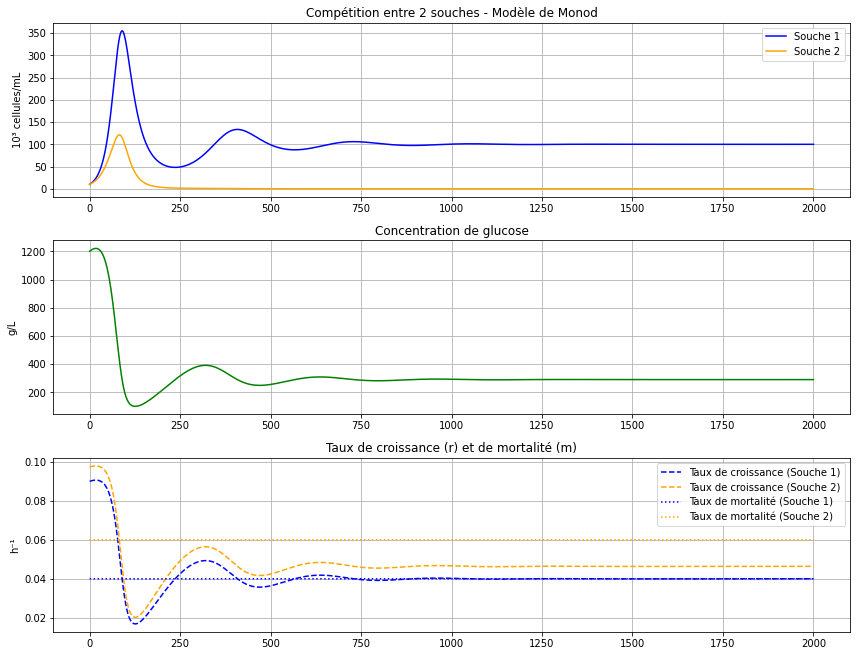

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.04      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()


La première courbe montre l'évolution de deux populations bactériennes en compétition pour la même ressource : le glucose.
Au début, le substrat est abondant, les deux souches se développent.
Ensuite, la ressource devient limitante, la croissance des souches ralentit. La souche ayant la meilleure efficacité d'utilisaiton du substrat (K) est avantagée quand la ressource diminue. La courbe du glucose décroît, ce qui explique la diminution progressive du taux de croissance.

Le résultat de la concurrence dépend surtout de l'acces au glucose. La souche la plus performante sur faible substrat finit souvent par dominer tandis que l'autre regresse et finit par disparaitre. cela correspond au principe de competition pour une source commune : les deux populations s'inhibent indirectemment en consommant le même milieu. 



La courbe des populations montre la montée initiale puis la séparation des deux souches. 
La courbe du glucise diminue car il est consommé par les deux souches.
Les taux de courbe de croissance dependent de la disponibilité du substrat dans le milieu.
Les courbes de mortalité restent horizontales si m est constant.

Actuellement : m0_1 = m0_2 = 0.06
J’ai fait varier m0_1 (taux de mortalité de base de la souche 1) tout en gardant les autres paramètres identiques.
Valeur critique trouvée :
La souche 1 l’emporte clairement sur la souche 2 lorsque :
m0_1 ≤ 0.052

À m0_1 = 0.053 → la souche 2 gagne encore (mais la différence se réduit).
À m0_1 = 0.052 → transition, les deux souches sont très proches.
À m0_1 = 0.050 ou moins → la souche 1 domine nettement et la souche 2 décline fortement.

Si Rmax augmente la souche concernée croît plus vite et prend plus facilement l'avantage.
Si K augmente la souche devient plus competitive à faible concentration de substrat.
Si k diminue la souche devient moins competitive à faible concentration de substrat.

Dans un modèle de compétition à une seule ressource (glucose), la coexistence stable est très difficile).
une seule souche domine généralement celle qui maintient la concentration de glucose la plus basse (valeur de R* la plus faible).
Pour que les deux souches coexistent à l’équilibre, il faut principalement :
Que R₁* = R₂* (les deux souches ont le même R*)
Ou un flux entrant de glucose (glucose_inflow) suffisamment élevé, qui empêche la concentration de ressource de descendre jusqu’au R* le plus bas
ans nos simulations (avec un faible inflow et une mortalité constante), les deux souches ne coexistent pas de façon durable. L’une finit toujours par éliminer l’autre, même si les R* sont proches.





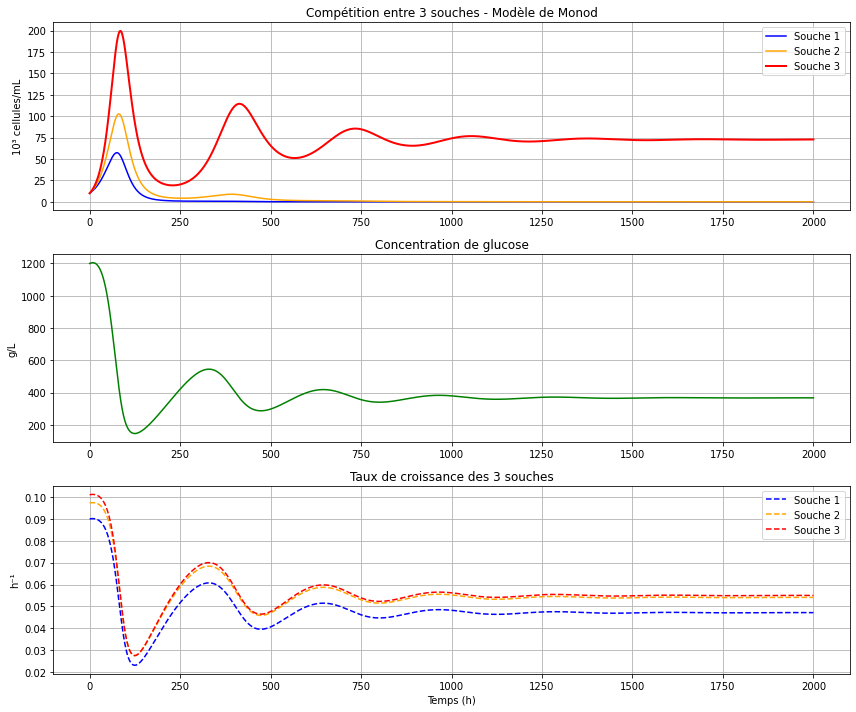

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15
m0_1 = 0.06
K_1 = 800

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15
m0_2 = 0.06
K_2 = 650

# =============================================
# Paramètres pour la souche 3 (NOUVELLE)
# =============================================
rmax_3 = 0.16      # Légèrement plus rapide
m0_3 = 0.055       # Mortalité un peu plus faible
K_3 = 700          # Affinité intermédiaire

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200
glucose_inflow = 4

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10
C0_2 = 10
C0_3 = 10

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1
T = 2000
N_steps = int(T / dt)

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
C3 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
C3[0] = C0_3
glucose_level[0] = initial_glucose

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Taux de croissance (Modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    r_3 = rmax_3 * glucose_level[i-1] / (K_3 + glucose_level[i-1])

    # Mortalité constante
    m_1 = m0_1
    m_2 = m0_2
    m_3 = m0_3
    
    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]
    C3[i] = C3[i-1] + dt * (r_3 - m_3) * C3[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1] + r_3 * C3[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

# =============================================
# Temps
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 10))

# Population des bactéries
plt.subplot(3, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.plot(time, C3, label='Souche 3', color='red', linewidth=2)
plt.title('Compétition entre 3 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(3, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance
plt.subplot(3, 1, 3)
plt.plot(time, rmax_1 * glucose_level / (K_1 + glucose_level), label='Souche 1', color='blue', linestyle='--')
plt.plot(time, rmax_2 * glucose_level / (K_2 + glucose_level), label='Souche 2', color='orange', linestyle='--')
plt.plot(time, rmax_3 * glucose_level / (K_3 + glucose_level), label='Souche 3', color='red', linestyle='--')
plt.title('Taux de croissance des 3 souches')
plt.xlabel('Temps (h)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


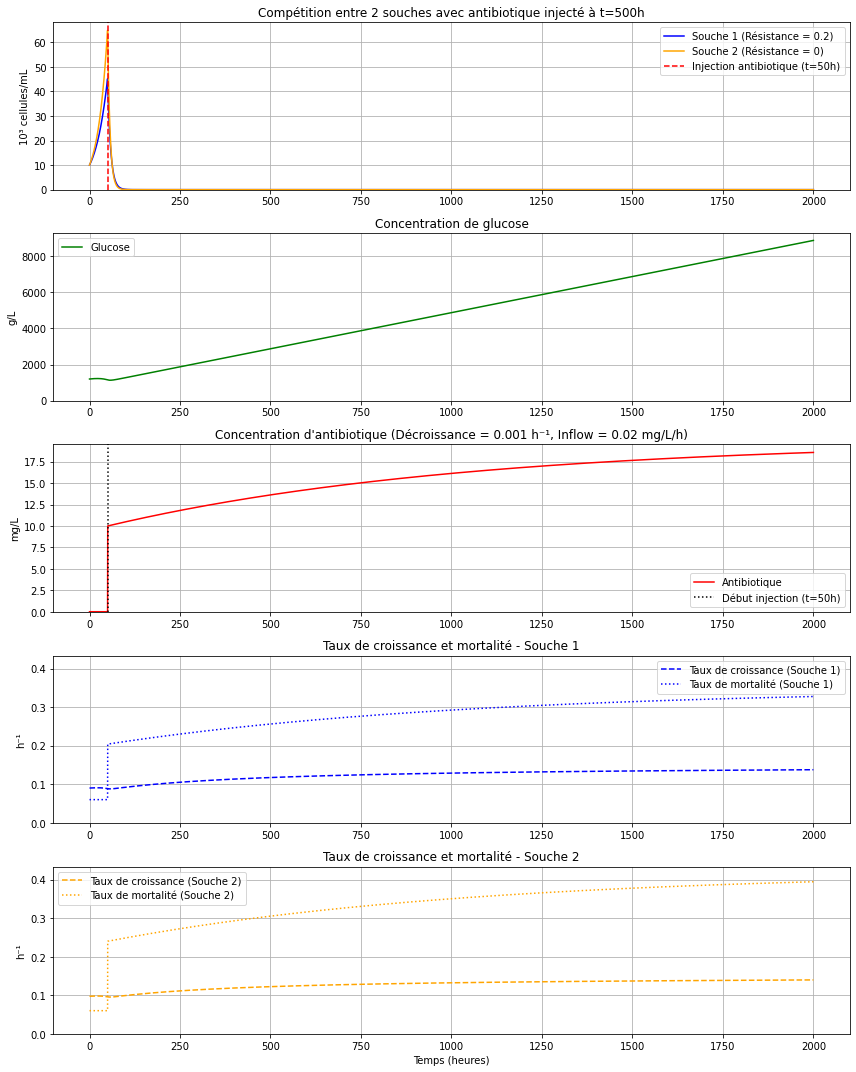

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.06        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0.2  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.06        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 4      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.001    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0.02      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 2000          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()


Lorsque l’antibiotique est injecté à t = 50 h avec une concentration initiale de 10 mg/L et que les deux souches sont sensibles (resistance_1 = 0 et resistance_2 = 0), les deux populations chutent brutalement après l’injection suite à l’augmentation importante de leur taux de mortalité. 
Avant l’injection, la souche 2 domine grâce à sa meilleure affinité pour le glucose. 
Après l’injection, les deux souches sont fortement affectées, la souche 2 restant toutefois majoritaire mais à des densités beaucoup plus faibles. Le glucose remonte légèrement après la chute des populations.
Lorsque la souche 1 est totalement résistante (resistance_1 = 1), l’antibiotique n’a aucun effet sur elle tandis que la souche 2 reste sensible. 
Avant l’injection, la souche 2 est dominante. 
Après l’injection à t = 50 h, la population de la souche 2 s’effondre rapidement tandis que la souche 1, protégée, profite de la disparition de sa concurrente et croît fortement pour devenir largement majoritaire à long terme.
Avec une résistance partielle de la souche 1 (resistance_1 = 0.2), les deux souches sont affectées par l’antibiotique mais la souche 1 l’est moins sévèrement. 
Après l’injection, la souche 2 décline fortement tandis que la souche 1 subit une baisse modérée puis récupère progressivement.
À long terme, la souche 1 domine grâce à son avantage en résistance, même si cette domination s’installe plus lentement que dans le cas d’une résistance totale.
Enfin, en simulant une pollution diffuse avec un inflow continu d’antibiotique (antibiotic_inflow = 0.02), la concentration d’antibiotique augmente progressivement et se stabilise à un niveau faible mais constant. 
Les deux souches voient leur mortalité augmenter en permanence, ce qui réduit fortement les populations globales. La souche 2 reste majoritaire grâce à sa meilleure compétitivité pour le glucose, mais les densités bactériennes sont nettement plus faibles qu’en l’absence d’antibiotique.
ce modèle illustre le pjénomène de sélection naturelle. L’antibiotique agit comme une pression de sélection qui favorise les souches résistantes, leur permettant de survivre et de dominer la population au détriment des souches sensibles.